# ⚙️ Feature Engineering — Creating Better Features for Machine Learning
**Step 2: Data Science → Topic 07 → Class 23** | Date: February 14, 2024 🎯

> **Feature Engineering = turning raw data into useful information a Machine Learning model can learn from.**

## 🎯 Learning Objectives
- Feature creation, transformation, extraction, selection
- Date/time, numerical, categorical, text features
- Encoding (binary, ordinal, one-hot) and scaling (Standard, MinMax)
- Interaction, ratio, aggregation features
- Missing-value indicators, constant & high-cardinality features
- **Data leakage** and safe train/test preprocessing (Pipeline)
- Polynomial features and PCA (intro)

💡 **How to use with YOUR data:** replace the sample-data cell with `df = pd.read_csv("your_file.csv")` and rename columns.

## 🧠 Key Concepts

**Feature** = an input variable describing an observation. **Target/Label** = the value we predict.

```text
Features: Age, Study_Hours, Attendance, Previous_Marks
Target:   Final_Marks
```

**A good feature:** meaningful, relevant, available at prediction time, consistent, no future information (no leakage).

### 🔄 Workflow
```text
Raw Data → Understand → EDA → Create/Transform → Encode → Scale → Select → Validate → ML
```

### 🗂️ Categories
```text
Feature Creation | Transformation | Extraction | Encoding | Scaling | Selection
Date/Time | Text | Numerical | Categorical | Interaction | Dimensionality Reduction
```

## 🛠️ 0. Setup & Sample Data

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("Setup complete ✅")

Setup complete ✅


In [12]:
# 📦 Sample Student Performance dataset (replace with pd.read_csv("your_file.csv"))
rng = np.random.default_rng(42)
n = 200

students = pd.DataFrame({
    "Student_ID": range(1001, 1001 + n),
    "Age": rng.integers(17, 26, n),
    "Gender": rng.choice(["Male", "Female"], n),
    "City": rng.choice(["Islamabad", "Lahore", "Karachi"], n),
    "Education": rng.choice(["School", "Bachelor", "Master", "PhD"], n),
    "Has_Loan": rng.choice(["Yes", "No"], n),
    "Study_Hours": rng.uniform(0, 8, n).round(1),
    "Attendance": rng.integers(40, 100, n).astype(float),
    "Previous_Marks": rng.integers(35, 95, n),
})
students["Final_Marks"] = (
    0.4 * students["Previous_Marks"] + 0.3 * students["Attendance"]
    + 3 * students["Study_Hours"] + rng.normal(0, 5, n)
).clip(0, 100).round()

# add some missing values + a skewed salary column + height/weight
students.loc[rng.choice(n, 15, replace=False), "Attendance"] = np.nan
students["Salary"] = (rng.lognormal(10.5, 0.9, n)).round()
students["Height_m"] = rng.normal(1.68, 0.09, n).round(2)
students["Weight_kg"] = rng.normal(68, 11, n).round(1)
students["Country"] = "Pakistan"   # constant column (for demo)

df = students.copy()
df.head()

,Student_ID,Age,Gender,City,Education,Has_Loan,Study_Hours,Attendance,Previous_Marks,Final_Marks,Salary,Height_m,Weight_kg,Country
0,1001,17,Male,Karachi,Master,Yes,5.9,91.0,53,63.0,38397.0,1.75,71.6,Pakistan
1,1002,23,Female,Karachi,PhD,Yes,7.1,54.0,79,69.0,40109.0,1.69,76.6,Pakistan
2,1003,22,Male,Islamabad,Master,No,7.4,57.0,84,74.0,25147.0,1.70,59.1,Pakistan
3,1004,20,Female,Karachi,School,No,4.0,59.0,54,46.0,10319.0,1.56,77.7,Pakistan
4,1005,20,Male,Lahore,PhD,No,4.2,50.0,42,48.0,9052.0,1.68,52.9,Pakistan


In [13]:
# 📦 Sample E-commerce dataset (orders) for date, aggregation, text features
orders = pd.DataFrame({
    "Order_ID": range(1, 301),
    "Customer_ID": rng.integers(1, 41, 300),
    "Order_Date": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 120, 300), unit="D"),
    "Price": rng.integers(500, 5000, 300),
    "Quantity": rng.integers(1, 6, 300),
    "Review": rng.choice([
        "This product is excellent!", "Bad quality, not happy",
        "Good value for money", "Delivery was late but product is fine",
        "Amazing, highly recommended", "Average product"], 300),
})
orders["Delivery_Date"] = orders["Order_Date"] + pd.to_timedelta(rng.integers(1, 10, 300), unit="D")
orders["Amount"] = orders["Price"] * orders["Quantity"]
orders.head()

,Order_ID,Customer_ID,Order_Date,Price,Quantity,Review,Delivery_Date,Amount
0,1,32,2024-04-28,1617,1,This product is excellent!,2024-05-03,1617
1,2,25,2024-04-20,2011,4,"Bad quality, not happy",2024-04-23,8044
2,3,20,2024-04-18,2554,2,"Bad quality, not happy",2024-04-22,5108
3,4,19,2024-03-10,1956,4,Good value for money,2024-03-13,7824
4,5,3,2024-04-05,2273,3,Average product,2024-04-06,6819


## 1️⃣ Feature Creation
Create a new feature from existing information — based on **domain knowledge**, not random columns.

Example: `BMI = Weight / Height²`

In [14]:
df["BMI"] = df["Weight_kg"] / (df["Height_m"] ** 2)
df[["Height_m", "Weight_kg", "BMI"]].head()

,Height_m,Weight_kg,BMI
0,1.75,71.6,23.379592
1,1.69,76.6,26.819789
2,1.70,59.1,20.449827
3,1.56,77.7,31.928008
4,1.68,52.9,18.742914


## 2️⃣ Date & Time Features
Dates hide lots of information: year, month, day, weekday, quarter, weekend...

In [15]:
o = orders.copy()
o["Order_Date"] = pd.to_datetime(o["Order_Date"])

o["Year"] = o["Order_Date"].dt.year
o["Month"] = o["Order_Date"].dt.month
o["Day"] = o["Order_Date"].dt.day
o["DayOfWeek"] = o["Order_Date"].dt.dayofweek       # Monday=0
o["Quarter"] = o["Order_Date"].dt.quarter
o["Week"] = o["Order_Date"].dt.isocalendar().week.astype(int)

# time-based flags
o["Is_Weekend"] = (o["Order_Date"].dt.dayofweek >= 5).astype(int)
o["Is_Month_Start"] = o["Order_Date"].dt.is_month_start.astype(int)
o["Is_Month_End"] = o["Order_Date"].dt.is_month_end.astype(int)

o[["Order_Date", "Year", "Month", "Day", "DayOfWeek", "Quarter", "Is_Weekend"]].head()

,Order_Date,Year,Month,Day,DayOfWeek,Quarter,Is_Weekend
0,2024-04-28,2024,4,28,6,2,1
1,2024-04-20,2024,4,20,5,2,1
2,2024-04-18,2024,4,18,3,2,0
3,2024-03-10,2024,3,10,6,1,1
4,2024-04-05,2024,4,5,4,2,0


## 3️⃣ Numerical Transformation — Log
Useful for **heavily right-skewed positive** variables (salary, price, income).

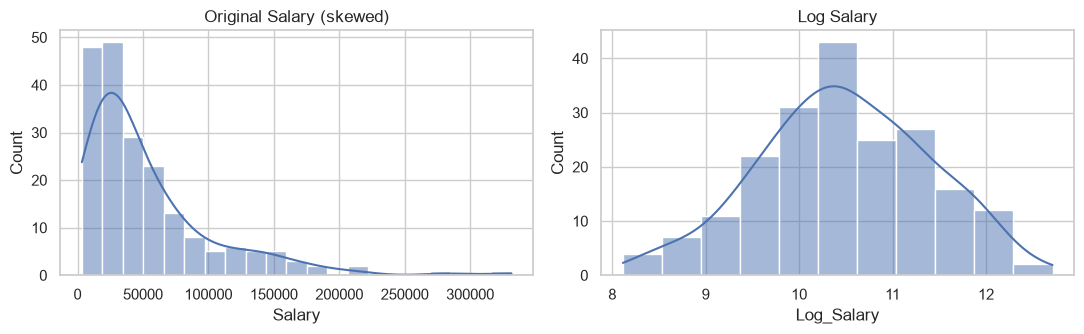

Skew before: 2.18 | after: -0.1


In [16]:
df["Log_Salary"] = np.log1p(df["Salary"])   # log1p handles zeros safely

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df["Salary"], kde=True, ax=ax[0]).set_title("Original Salary (skewed)")
sns.histplot(df["Log_Salary"], kde=True, ax=ax[1]).set_title("Log Salary")
plt.tight_layout(); plt.show()
print("Skew before:", round(df["Salary"].skew(), 2), "| after:", round(df["Log_Salary"].skew(), 2))

## 4️⃣ Binning / Discretization
Convert continuous values into groups. ⚠️ Don't bin automatically — you lose precision.

In [17]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 21, 24, 100],
    labels=["Teen", "Young Adult", "Adult", "Senior"]
)

# quantile-based bins (equal number of rows per bin)
df["Marks_Category"] = pd.qcut(
    df["Previous_Marks"], q=3, labels=["Low", "Medium", "High"]
)
df[["Age", "Age_Group", "Previous_Marks", "Marks_Category"]].head()

,Age,Age_Group,Previous_Marks,Marks_Category
0,17,Teen,53,Low
1,23,Adult,79,High
2,22,Adult,84,High
3,20,Young Adult,54,Low
4,20,Young Adult,42,Low


## 5️⃣ Categorical Encoding
| Type | Example | Approach |
|---|---|---|
| Nominal | City, Color | One-Hot |
| Binary | Yes/No | Map to 1/0 |
| Ordinal | Low/Med/High, Education | Ordinal encoding |

⚠️ `Red=1, Blue=2, Green=3` does **not** mean Green > Blue > Red.

In [18]:
# Binary encoding
df["Has_Loan_Enc"] = df["Has_Loan"].map({"Yes": 1, "No": 0})

# Ordinal encoding (meaningful order)
edu_order = {"School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df["Education_Enc"] = df["Education"].map(edu_order)

df[["Has_Loan", "Has_Loan_Enc", "Education", "Education_Enc"]].head()

,Has_Loan,Has_Loan_Enc,Education,Education_Enc
0,Yes,1,Master,2
1,Yes,1,PhD,3
2,No,0,Master,2
3,No,0,School,0
4,No,0,PhD,3


In [19]:
# One-Hot Encoding (nominal). drop_first=True avoids redundant column for linear models
city_dummies = pd.get_dummies(df["City"], prefix="City", dtype=int)
df_encoded = pd.concat([df, city_dummies], axis=1)
df_encoded[["City", "City_Islamabad", "City_Lahore", "City_Karachi"]].head()

,City,City_Islamabad,City_Lahore,City_Karachi
0,Karachi,0,0,1
1,Karachi,0,0,1
2,Islamabad,1,0,0
3,Karachi,0,0,1
4,Lahore,0,1,0


## 6️⃣ Feature Scaling
Different ranges (Age 18–70, Salary 20k–500k) hurt distance/gradient-based models.

| | StandardScaler | MinMaxScaler |
|---|---|---|
| Centered at 0 | Yes | No |
| Range | Not fixed | 0–1 |
| Uses | mean/std | min/max |
| Outlier sensitive | Yes | Yes |

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

cols = ["Age", "Salary"]
std_scaled = pd.DataFrame(StandardScaler().fit_transform(df[cols]), columns=[c + "_std" for c in cols])
mm_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df[cols]), columns=[c + "_mm" for c in cols])

print(std_scaled.describe().loc[["mean", "std"]].round(2))
print(mm_scaled.describe().loc[["min", "max"]].round(2))
# ⚠️ Demo only! In real ML, fit the scaler on TRAIN data only (see Data Leakage section).

ModuleNotFoundError: No module named 'sklearn'

## 7️⃣ Interaction & Ratio Features
Relationships between columns that individual columns don't capture.

In [ ]:
# Interaction
df["Study_x_Attendance"] = df["Study_Hours"] * df["Attendance"]
orders["Total_Spending"] = orders["Price"] * orders["Quantity"]

# Ratio — handle zero / missing denominators safely
df["Study_Efficiency"] = df["Study_Hours"] / df["Attendance"].replace(0, np.nan)

df[["Study_Hours", "Attendance", "Study_x_Attendance", "Study_Efficiency"]].head()

## 8️⃣ Aggregation Features
Summarize grouped/historical info (e-commerce, finance, recommendation systems).

In [ ]:
customer_summary = orders.groupby("Customer_ID").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Spending=("Amount", "sum"),
    Average_Order=("Amount", "mean"),
).reset_index()
customer_summary.head()

## 9️⃣ Text Features (simple)
Advanced text features later: TF-IDF, Bag of Words, Embeddings, Transformers (NLP/LLMs).

In [ ]:
orders["Review_Length"] = orders["Review"].str.len()
orders["Word_Count"] = orders["Review"].str.split().str.len()
orders[["Review", "Review_Length", "Word_Count"]].head()

In [ ]:
# Preview of TF-IDF (used later in NLP)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=8, stop_words="english")
X_text = tfidf.fit_transform(orders["Review"])
pd.DataFrame(X_text.toarray(), columns=tfidf.get_feature_names_out()).head()

## 🔟 Missing-Value Indicators
Missingness itself can be informative — keep a flag, then impute.

In [ ]:
df["Attendance_Missing"] = df["Attendance"].isna().astype(int)
df["Attendance_Filled"] = df["Attendance"].fillna(df["Attendance"].median())
print("Missing before:", df["Attendance"].isna().sum(), "| after:", df["Attendance_Filled"].isna().sum())

## 1️⃣1️⃣ Domain-Knowledge Features
The best features come from understanding the business problem.

In [ ]:
orders["Delivery_Days"] = (orders["Delivery_Date"] - orders["Order_Date"]).dt.days
orders[["Order_Date", "Delivery_Date", "Delivery_Days"]].head()

## 1️⃣2️⃣ Feature Selection
Remove noise, complexity, compute cost, and overfitting risk.

```text
Filter:   Correlation, Variance, Statistical tests
Wrapper:  RFE, Sequential selection
Embedded: Lasso, Tree importance, Regularization
```

In [ ]:
# Constant features
print("Unique values in Country:", df["Country"].nunique(), "→ constant, drop it")

# High-cardinality / ID columns — identify the record, not a pattern
for col in ["Student_ID", "City", "Gender"]:
    print(f"{col}: {df[col].nunique()} unique / {len(df)} rows")

In [ ]:
# Auto-detect constant + ID-like columns
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
id_like_cols = [c for c in df.columns if df[c].nunique() == len(df)]
print("Constant:", constant_cols)
print("ID-like:", id_like_cols)

Study_Hours       0.679
Previous_Marks    0.659
Attendance        0.397
Age               0.190
Salary            0.167
Log_Salary        0.108
BMI               0.107
Has_Loan_Enc      0.084
Weight_kg         0.069
Student_ID        0.064
Education_Enc     0.037
Height_m         -0.068
Name: Final_Marks, dtype: float64


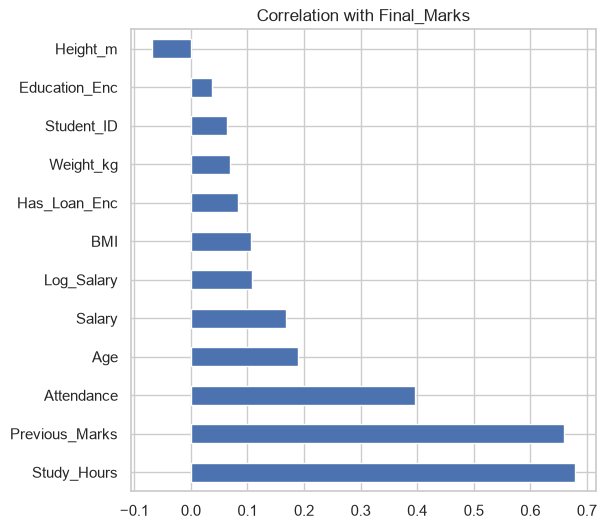

In [22]:
# Filter method: correlation with target
num_df = df.select_dtypes(include="number")
corr = num_df.corr()["Final_Marks"].drop("Final_Marks").sort_values(ascending=False)
print(corr.round(3))

plt.figure(figsize=(6, 6))
corr.plot(kind="barh"); plt.title("Correlation with Final_Marks"); plt.show()

In [25]:
pip install scikit-learn

  Using cached scipy-1.18.1-cp314-cp314-macosx_10_15_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.4 MB/s  0:00:02 eta 0:00:01
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached scipy-1.18.1-cp314-cp314-macosx_10_15_x86_64.whl (31.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
# Variance threshold + tree-based importance
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor

feat_cols = ["Age", "Study_Hours", "Attendance_Filled", "Previous_Marks",
             "Study_x_Attendance", "BMI", "Education_Enc", "Has_Loan_Enc"]
X_sel, y_sel = df[feat_cols], df["Final_Marks"]

vt = VarianceThreshold(threshold=0.01).fit(X_sel)
print("Kept by variance:", list(X_sel.columns[vt.get_support()]))

rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_sel, y_sel)
pd.Series(rf.feature_importances_, index=feat_cols).sort_values().plot(kind="barh", title="Tree Importance")
plt.show()

KeyError: "['Attendance_Filled', 'Study_x_Attendance'] not in index"

## ⚠️ 1️⃣3️⃣ Data Leakage (MOST IMPORTANT ML CONCEPT)
Leakage = information that would **not** be available at prediction time gets into features/preprocessing.

- Predicting order cancellation but using `Cancellation_Date` ❌
- Fitting a scaler/imputer/encoder on the **whole** dataset before the split ❌

```text
Split first → Fit preprocessing on TRAIN → Transform TRAIN → Transform TEST
```
Applies to: scaling, imputation, encoding, feature selection, target-based features.

In [ ]:
from sklearn.model_selection import train_test_split

features = ["Age", "Study_Hours", "Attendance", "Previous_Marks"]
X = df[features]; y = df["Final_Marks"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ❌ WRONG: scaler.fit on all data
# ✅ RIGHT: fit on train only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.fillna(X_train.median()))   # learn from train
X_test_s = scaler.transform(X_test.fillna(X_train.median()))         # only apply to test
print("Train mean ≈", X_train_s.mean().round(3), "| Test mean (not exactly 0 — that's correct!):", X_test_s.mean().round(3))

## 🔐 1️⃣4️⃣ Production-Style: `Pipeline` + `ColumnTransformer`
Keeps preprocessing consistent and prevents leakage automatically. 🎯 **Interview tip:** very commonly asked.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

num_features = ["Age", "Study_Hours", "Attendance", "Previous_Marks"]
cat_features = ["Gender", "City"]

X = df[num_features + cat_features]
y = df["Final_Marks"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
])

for name, model in [("Linear Regression", LinearRegression()),
                    ("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42))]:
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f"{name:18s} R²: {r2_score(y_test, pred):.3f} | MAE: {mean_absolute_error(y_test, pred):.2f}")

NameError: name 'train_test_split' is not defined

## 🧮 1️⃣5️⃣ Polynomial Features
Help models capture non-linear relationships — but dimensionality grows fast.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[["Study_Hours", "Previous_Marks"]])
print("Original shape:", df[["Study_Hours", "Previous_Marks"]].shape, "→ Poly shape:", X_poly.shape)
print(poly.get_feature_names_out())

## 📉 1️⃣6️⃣ Dimensionality Reduction — PCA (intro)
Deeper coverage comes in Machine Learning.

In [ ]:
from sklearn.decomposition import PCA

num_cols = ["Age", "Study_Hours", "Attendance_Filled", "Previous_Marks", "BMI", "Log_Salary"]
Xs = StandardScaler().fit_transform(df[num_cols])
pca = PCA(n_components=3).fit(Xs)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Cumulative:", pca.explained_variance_ratio_.cumsum().round(3))

## 🆚 Comparison Tables

| Feature Engineering | Feature Selection |
|---|---|
| Creates/transforms features | Chooses useful features |
| Improves representation | Removes unnecessary ones |
| Uses domain knowledge | Uses statistical/model methods |

| Data Cleaning | Feature Engineering |
|---|---|
| Fixes quality problems | Creates useful representations |
| Missing values, duplicates, wrong types | Interactions, encoding, scaling, ratios |

```text
Data Cleaning → make data reliable
Feature Engineering → make information useful for the model
```

## 🧪 Mini Project — Student Performance Feature Engineering
Create these on the student dataset:
1. `Age_Group`
2. `Study_Efficiency = Study_Hours / Attendance` (handle zero/missing)
3. `Previous_Performance` category (Low/Medium/High)
4. `Attendance_Category` (Low/Medium/High)
5. `Performance_Change = Final_Marks - Previous_Marks`
6. `Study_x_Attendance`
7. Compare original vs engineered features → correlation → visualization → model performance

⚠️ Note: `Performance_Change` uses `Final_Marks` (the target) — it's fine for **analysis**, but it is **leakage** if used as a feature to predict `Final_Marks`!

In [ ]:
proj = students.copy()

proj["Age_Group"] = pd.cut(proj["Age"], [0, 18, 21, 24, 100], labels=["Teen", "Young Adult", "Adult", "Senior"])
proj["Attendance_Filled"] = proj["Attendance"].fillna(proj["Attendance"].median())
proj["Study_Efficiency"] = proj["Study_Hours"] / proj["Attendance_Filled"].replace(0, np.nan)
proj["Previous_Performance"] = pd.qcut(proj["Previous_Marks"], 3, labels=["Low", "Medium", "High"])
proj["Attendance_Category"] = pd.cut(proj["Attendance_Filled"], [0, 60, 80, 100], labels=["Low", "Medium", "High"])
proj["Performance_Change"] = proj["Final_Marks"] - proj["Previous_Marks"]   # analysis only!
proj["Study_x_Attendance"] = proj["Study_Hours"] * proj["Attendance_Filled"]

proj[["Age_Group", "Study_Efficiency", "Previous_Performance",
      "Attendance_Category", "Performance_Change", "Study_x_Attendance"]].head()

In [ ]:
# Correlation of original vs engineered features with the target
check = ["Study_Hours", "Attendance_Filled", "Previous_Marks", "Study_Efficiency", "Study_x_Attendance"]
corr = proj[check + ["Final_Marks"]].corr()["Final_Marks"].drop("Final_Marks").sort_values()
corr.plot(kind="barh", title="Correlation with Final_Marks"); plt.show()

In [ ]:
# Model comparison: original vs original + engineered (NO leaky features)
def score(cols):
    Xp = proj[cols].fillna(proj[cols].median())
    Xtr, Xte, ytr, yte = train_test_split(Xp, proj["Final_Marks"], test_size=0.2, random_state=42)
    m = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)
    return r2_score(yte, m.predict(Xte))

original = ["Age", "Study_Hours", "Attendance_Filled", "Previous_Marks"]
engineered = original + ["Study_Efficiency", "Study_x_Attendance"]
print(f"Original   R²: {score(original):.3f}")
print(f"Engineered R²: {score(engineered):.3f}")

## ✅ Feature Dictionary Template
| Feature | Meaning | Type | Source |
|---|---|---|---|
| `age` | Customer age | Numerical | DOB |
| `total_spending` | Total customer spending | Numerical | Orders |
| `city_lahore` | Lives in Lahore | Binary | City |
| `delivery_days` | Delivery duration | Numerical | Dates |

## ⭐ Tips
1. Start with the problem. 2. Use domain knowledge. 3. Don't create hundreds of random features.
4. Watch for leakage. 5. Preserve original columns while experimenting.
6. Validate: `.describe()`, `.isnull().sum()`. 7. Keep a feature dictionary.

## 🧠 What to MEMORIZE vs REFERENCE
| 🧠 Memorize | 📖 Reference |
|---|---|
| Nominal vs ordinal encoding rule | Exact `pd.cut` / `qcut` arguments |
| Split → fit on train → transform test | Sklearn import paths |
| Leakage definition + examples | Scaler formulas |
| Pipeline + ColumnTransformer idea | Date `.dt` attributes |

## 🎯 Key Takeaways
```text
RAW → UNDERSTAND → CLEAN → EXPLORE → CREATE → TRANSFORM → ENCODE → SCALE → SELECT → VALIDATE → ML
```
> **“Can I represent this raw information in a way that gives the model a useful signal without introducing leakage?”**

## ❓ Interview Questions
**Beginner:** 1. What is Feature Engineering? 2. What is a feature? 3. Why is it important? 4. Feature creation? 5. Feature transformation? 6. Feature selection? 7. One-Hot Encoding? 8. Feature scaling?

**Intermediate:** 9. When use One-Hot? 10. Nominal vs ordinal? 11. Standardization? 12. Min-Max scaling? 13. StandardScaler vs MinMaxScaler? 14. Interaction features? 15. Ratio features? 16. Feature extraction? 17. Dimensionality reduction? 18. High-cardinality data?

**Important ML:** 19. What is data leakage? 20. How can FE cause leakage? 21. Fit a scaler on the full dataset before splitting? 22. Why learn preprocessing from train only? 23. How does domain knowledge help? 24. Do more features always help? 25. How do you know an engineered feature is useful?
